In [34]:
from sympy import symbols, Rational
from sympy.utilities.codegen import codegen
from sympy.codegen.rewriting import optimize, optims_c99
from sympy.simplify.cse_main import cse
import sympy as sp
from sympy import S
from sympy.printing.c import C99CodePrinter, Assignment
from sympy import init_printing
from codegen.codegen_utils import * 
init_printing()
printer = MyPrinter() 
from sympy.calculus.finite_diff import finite_diff_weights

i, j, k = symbols('i j k', cls=sp.Idx)
h, invh = sp.symbols('h invh')
x0 = 0

#---------------------------------------------------------------------------#
# 1. Build a single-direction FD stencil as a dict
#---------------------------------------------------------------------------#
def fd_1d_stencil(order, shift, direction):
    # x positions in the 1D stencil
    xlist = [ii*h + x0 for ii in range(-(order//2), order//2+1)]
    xlist = [x + shift*h for x in xlist]

    # 1st derivative FD weights
    coeffs = finite_diff_weights(1, xlist, x0)[-1][-1]

    # Return stencil as {(dx,dy,dz): weight}
    stencil = {}
    center = -(order//2) + shift

    for s, w in enumerate(coeffs):
        if direction == "x":
            stencil[(center + s, 0, 0)] = w
        elif direction == "y":
            stencil[(0, center + s, 0)] = w
        else:
            stencil[(0, 0, center + s)] = w

    return stencil

#---------------------------------------------------------------------------#
# 1. Build a single-direction FD stencil as a dict
#---------------------------------------------------------------------------#
def fd_second_1d_stencil(order, shift, direction):
    # x positions in the 1D stencil
    xlist = [ii*h + x0 for ii in range(-((order)//2), order//2+1)]
    xlist = [x + shift*h for x in xlist]

    # 1st derivative FD weights
    coeffs = finite_diff_weights(2, xlist, x0)[-1][-1]

    # Return stencil as {(dx,dy,dz): weight}
    stencil = {}
    center = -(order//2) + shift

    for s, w in enumerate(coeffs):
        if direction == "x":
            stencil[(center + s, 0, 0)] = w
        elif direction == "y":
            stencil[(0, center + s, 0)] = w
        else:
            stencil[(0, 0, center + s)] = w

    return stencil

def fd_gen_1d_stencil(order, der_order, shift, direction):
    # x positions in the 1D stencil
    xlist = [ii*h + x0 for ii in range(-((der_order+order-1)//2), (der_order+order-1)//2+1)]
    xlist = [x + shift*h for x in xlist]

    # 1st derivative FD weights
    coeffs = finite_diff_weights(der_order, xlist, x0)[-1][-1]

    # Return stencil as {(dx,dy,dz): weight}
    stencil = {}
    center = -((der_order+order-1)//2) + shift

    for s, w in enumerate(coeffs):
        if direction == "x":
            stencil[(center + s, 0, 0)] = w
        elif direction == "y":
            stencil[(0, center + s, 0)] = w
        else:
            stencil[(0, 0, center + s)] = w

    return stencil

#---------------------------------------------------------------------------#
# 2. Convolution of stencils (composition of derivatives)
#---------------------------------------------------------------------------#
def convolve_stencils(A, B):
    """
    Convolution of two stencils A and B:
      A ∘ B applied to u yields a new stencil.
    A and B are dicts {(dx,dy,dz): coeff}.
    """
    out = {}
    for (ax,ay,az), av in A.items():
        for (bx,by,bz), bv in B.items():
            key = (ax+bx, ay+by, az+bz)
            out[key] = out.get(key, 0) + av*bv
    return out


#---------------------------------------------------------------------------#
# 3. General mixed derivative: directions = ["x","y"], shifts = [0,1], etc.
#---------------------------------------------------------------------------#
def mixed_fd_stencil(order, shifts, directions):
    """
    Returns a single combined stencil for d/d(direction[0]) ... d/d(direction[n-1]).
    """
    assert len(shifts) == len(directions)

    # Start with identity stencil
    stencil = {(0,0,0): 1}

    # Apply FD operators sequentially
    for shift, direction in zip(shifts, directions):
        op = fd_1d_stencil(order, shift, direction)
        stencil = convolve_stencils(stencil, op)

    return stencil


def get_symbol(name,dx,dy,dz):
    n = name + "("

    if dx>0:
        n += f"i+{dx},"
    elif dx < 0: 
        n += f"i-{abs(dx)}," 
    else: n+="i,"

    if dy>0:
        n += f"j+{dy},"
    elif dy < 0: 
        n += f"j-{abs(dy)}," 
    else: n+="j,"

    if dz>0:
        n += f"k+{dz})"
    elif dz < 0: 
        n += f"k-{abs(dz)})" 
    else: n+="k)"

    return sp.Symbol(n)

def factor_common_rational(expr):
    expr = sp.together(expr)        # put over common denominator
    num, den = expr.as_numer_denom()
    return sp.factor(num)/den


#---------------------------------------------------------------------------#
# 4. Turn a stencil into a SymPy expression u[i+dx, j+dy, k+dz]
#---------------------------------------------------------------------------#
def stencil_to_expression(stencil, name):
    expr = 0
    for (dx,dy,dz), w in stencil.items():
        u = get_symbol(name,dx,dy,dz)
        expr += w * u

    expr = expr.subs({"h": 1/invh})
    expr = sp.collect(expr, invh)

    # 👇 NEW: factor common denominator
    expr = factor_common_rational(expr)

    return expr



In [35]:
Dm = fd_1d_stencil(2,-1,"x")
DmDm = convolve_stencils(Dm,Dm)
print(stencil_to_expression(DmDm,"u"))

invh**2*(9*u(i,j,k) - 24*u(i-1,j,k) + 22*u(i-2,j,k) - 8*u(i-3,j,k) + u(i-4,j,k))/4


In [36]:
order = 1
print(list(range(-(order//2),(order)//2+1)))

[0]


In [37]:
print(stencil_to_expression(fd_second_1d_stencil(6,0,"x"),"u"))

invh**2*(270*u(i+1,j,k) - 27*u(i+2,j,k) + 2*u(i+3,j,k) - 490*u(i,j,k) + 270*u(i-1,j,k) - 27*u(i-2,j,k) + 2*u(i-3,j,k))/180


In [38]:
DER_ORDER = 6

In [39]:
s1 = {}
for d in ("x","y","z"):
    for shift in range(-1,2):
        s1[(d,shift)] = fd_1d_stencil(DER_ORDER,shift,d)
fd1 = {} 
for d in ("x","y","z"):
    for shift in range(-1,2):
        fd1[(d,shift)] = stencil_to_expression(s1[(d,shift)], "u")

s14 = {}
for d in ("x","y","z"):
    s14[(d,0)] = fd_1d_stencil(4,0,d)

fd14 = {} 
for d in ("x","y","z"):
    fd14[(d,0)] = stencil_to_expression(s14[(d,0)], "u")

In [40]:
# Second derivatives 
s2 = {} 
s2[("xx",0)] = fd_second_1d_stencil(DER_ORDER,0,"x")
s2[("yy",0)] = fd_second_1d_stencil(DER_ORDER,0,"y")
s2[("zz",0)] = fd_second_1d_stencil(DER_ORDER,0,"z")
for d in ("xy","xz","yz"):
    s2[(d,0)] = mixed_fd_stencil(DER_ORDER,[0,0],[d[0],d[1]])
fd2 = {} 
for k in s2.keys():
    fd2[k] = stencil_to_expression(s2[k], "u")

s12 = {}
for d in ("x","y","z"):
    for shift in range(-1,2):
        s12[(d,shift)] = fd_1d_stencil(2,shift,d)
fd12 = {} 
for d in ("x","y","z"):
    for shift in range(-1,2):
        fd12[(d,shift)] = stencil_to_expression(s12[(d,shift)], "u")

In [41]:
fdUpw = {} 
for d in ("x","y","z"):
    # beta < 0 
    # https://arxiv.org/pdf/1111.2177 Eq (71)
    fdUpw[(d,-1)] = stencil_to_expression(fd_1d_stencil(DER_ORDER,-1,d), "u") #+ Rational(1,2) * stencil_to_expression(fd_second_1d_stencil(DER_ORDER,-1,d),"u") / invh 
    # beta > 0 
    fdUpw[(d,+1)] = stencil_to_expression(fd_1d_stencil(DER_ORDER,+1,d), "u") #- Rational(1,2) * stencil_to_expression(fd_second_1d_stencil(DER_ORDER,+1,d),"u") / invh 
    # beta == 0 
    #fdUpw[(d,0)] = stencil_to_expression(fd_1d_stencil(DER_ORDER,0,d), "u")



In [42]:
p = DER_ORDER+1
fdDiss = {} 
for d in ("x","y","z"):
    fdDiss[d] = stencil_to_expression(fd_gen_1d_stencil(2,p+1,0,d), "u") * invh**(-p)

In [43]:
def get_fname(key):
    if key[1]==0:
        return f"fd_der_{key[0]}"
    else:
        if key[1]<0:
            return f"fd_der_{key[0]}_l{abs(key[1])}"
        else:
            return f"fd_der_{key[0]}_r{abs(key[1])}"
        
def get_fname_2nd(key):
    if key[1]==0:
        return f"fd_der_2_{key[0]}"
    else:
        if key[1]<0:
            return f"fd_der_2_{key[0]}_l{abs(key[1])}"
        else:
            return f"fd_der_2_{key[0]}_r{abs(key[1])}"
        
def get_fname_4th(key):
    if key[1]==0:
        return f"fd_der_4_{key[0]}"
    else:
        if key[1]<0:
            return f"fd_der_4_{key[0]}_l{abs(key[1])}"
        else:
            return f"fd_der_4_{key[0]}_r{abs(key[1])}"
        
def get_fname_upw(key):
    if (key[1]==-1): return f"fd_der_{key[0]}_upw_neg"
    elif (key[1]==+1): return f"fd_der_{key[0]}_upw_pos"
    else: raise ValueError("Unknown upwinding")
        

In [44]:
flist = [] 

output = ["du"]
out_abi = { "du": ("double",None) }
abi = {"u": ("view_t", None), "i": ("int", None), "j": ("int", None), "k": ("int",None), "h": ("double",None), "invh": ("double", None)}

for k,expr in fd1.items():
    flist.append(make_function([expr],printer,get_fname(k),abi,output,out_abi,template_args=[("typename","view_t")],additional_inputs=["i","j","k"],cse_optims=None))

for k,expr in fd14.items():
    flist.append(make_function([expr],printer,get_fname_4th(k),abi,output,out_abi,template_args=[("typename","view_t")],additional_inputs=["i","j","k"],cse_optims=None))

for k,expr in fd12.items():
    flist.append(make_function([expr],printer,get_fname_2nd(k),abi,output,out_abi,template_args=[("typename","view_t")],additional_inputs=["i","j","k"],cse_optims=None))

for k,expr in fd2.items():
    flist.append(make_function([expr],printer,get_fname(k),abi,output,out_abi,template_args=[("typename","view_t")],additional_inputs=["i","j","k"],cse_optims=None))

for k,expr in fdUpw.items():
    flist.append(make_function([expr],printer,get_fname_upw(k),abi,output,out_abi,template_args=[("typename","view_t")],additional_inputs=["i","j","k"],cse_optims=None))

for k,expr in fdDiss.items():
    flist.append(make_function([expr],printer,f"fd_diss_{k}",abi,output,out_abi,template_args=[("typename","view_t")],additional_inputs=["i","j","k"],cse_optims=None))



In [45]:
directions = ["x","y","z"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_deriv_scalar_4(view_t state, int i, int j, int k, int iv, int q, double d[3], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto u = subview(state,ALL(),ALL(),ALL(),iv,q);")
for i in range(3):
    fbody.append(f"fd_der_4_{directions[i]}(u,i,j,k,invh,&(d[{i}]));")
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

uc = ["ux","uy","uz"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_deriv_vector_4(view_t state, int i, int j, int k, int iv, int q, double d[9], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto ux = subview(state,ALL(),ALL(),ALL(),iv,q)  ;")
fbody.append("auto uy = subview(state,ALL(),ALL(),ALL(),iv+1,q);")
fbody.append("auto uz = subview(state,ALL(),ALL(),ALL(),iv+2,q);")
for idir in range(3):
    for icomp in range(3):
        fbody.append(f"fd_der_4_{directions[idir]}({uc[icomp]},i,j,k,invh,&(d[{icomp + 3*idir}]));")
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

uc = ["uxx","uxy","uxz","uyy","uyz","uzz"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_deriv_tensor_4(view_t state, int i, int j, int k, int iv, int q, double d[18], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto uxx = subview(state,ALL(),ALL(),ALL(),iv,q)  ;")
fbody.append("auto uxy = subview(state,ALL(),ALL(),ALL(),iv+1,q);")
fbody.append("auto uxz = subview(state,ALL(),ALL(),ALL(),iv+2,q);")
fbody.append("auto uyy = subview(state,ALL(),ALL(),ALL(),iv+3,q);")
fbody.append("auto uyz = subview(state,ALL(),ALL(),ALL(),iv+4,q);")
fbody.append("auto uzz = subview(state,ALL(),ALL(),ALL(),iv+5,q);")
for idir in range(3):
    for icomp in range(6):
        fbody.append(f"fd_der_4_{directions[idir]}({uc[icomp]},i,j,k,invh,&(d[{icomp + 6*idir}]));")
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [46]:
directions = ["x","y","z"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_deriv_scalar(view_t state, int i, int j, int k, int iv, int q, double d[3], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto u = subview(state,ALL(),ALL(),ALL(),iv,q);")
for i in range(3):
    fbody.append(f"fd_der_{directions[i]}(u,i,j,k,invh,&(d[{i}]));")
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [47]:
uc = ["ux","uy","uz"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_deriv_vector(view_t state, int i, int j, int k, int iv, int q, double d[9], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto ux = subview(state,ALL(),ALL(),ALL(),iv,q)  ;")
fbody.append("auto uy = subview(state,ALL(),ALL(),ALL(),iv+1,q);")
fbody.append("auto uz = subview(state,ALL(),ALL(),ALL(),iv+2,q);")
for idir in range(3):
    for icomp in range(3):
        fbody.append(f"fd_der_{directions[idir]}({uc[icomp]},i,j,k,invh,&(d[{icomp + 3*idir}]));")
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [48]:
uc = ["uxx","uxy","uxz","uyy","uyz","uzz"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_deriv_tensor(view_t state, int i, int j, int k, int iv, int q, double d[18], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto uxx = subview(state,ALL(),ALL(),ALL(),iv,q)  ;")
fbody.append("auto uxy = subview(state,ALL(),ALL(),ALL(),iv+1,q);")
fbody.append("auto uxz = subview(state,ALL(),ALL(),ALL(),iv+2,q);")
fbody.append("auto uyy = subview(state,ALL(),ALL(),ALL(),iv+3,q);")
fbody.append("auto uyz = subview(state,ALL(),ALL(),ALL(),iv+4,q);")
fbody.append("auto uzz = subview(state,ALL(),ALL(),ALL(),iv+5,q);")
for idir in range(3):
    for icomp in range(6):
        fbody.append(f"fd_der_{directions[idir]}({uc[icomp]},i,j,k,invh,&(d[{icomp + 6*idir}]));")
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [49]:
directions = ["x","y","z"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_deriv_scalar_upw(view_t state, int i, int j, int k, int iv, int q, double * d, double v[3], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto u = subview(state,ALL(),ALL(),ALL(),iv,q);")
fbody.append("(*d) = 0 ;")
fbody.append("double dl;")
for i in range(3):
    fbody.append("dl=0.0;")
    fbody.append(f"if (v[{i}]>0)" + "{")
    fbody.append(f"\tfd_der_{directions[i]}_upw_pos(u,i,j,k,invh,&(dl));")
    fbody.append("}" + f"else if (v[{i}]<0)" + "{")
    fbody.append(f"\tfd_der_{directions[i]}_upw_neg(u,i,j,k,invh,&(dl));")
    fbody.append("}")
    fbody.append(f"(*d) += dl * v[{i}];")
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [50]:
uc = ["ux","uy","uz"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_deriv_vector_upw(view_t state, int i, int j, int k, int iv, int q, double d[3], double v[3], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto ux = subview(state,ALL(),ALL(),ALL(),iv,q)  ;")
fbody.append("auto uy = subview(state,ALL(),ALL(),ALL(),iv+1,q);")
fbody.append("auto uz = subview(state,ALL(),ALL(),ALL(),iv+2,q);")
fbody.append("double dl;")
for icomp in range(3):
    fbody.append(f"d[{icomp}] = 0;")
    for idir in range(3):
        fbody.append("dl=0.0;")
        fbody.append(f"if (v[{idir}]>0)" + "{")
        fbody.append(f"\tfd_der_{directions[idir]}_upw_pos({uc[icomp]},i,j,k,invh,&(dl));")
        fbody.append("}" + f"else if (v[{idir}]<0)" + "{")
        fbody.append(f"\tfd_der_{directions[idir]}_upw_neg({uc[icomp]},i,j,k,invh,&(dl));")
        fbody.append("}")

        fbody.append(f"d[{icomp}] += dl * v[{idir}];")
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [51]:
uc = ["uxx","uxy","uxz","uyy","uyz","uzz"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_deriv_tensor_upw(view_t state, int i, int j, int k, int iv, int q, double d[6], double v[3], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto uxx = subview(state,ALL(),ALL(),ALL(),iv,q)  ;")
fbody.append("auto uxy = subview(state,ALL(),ALL(),ALL(),iv+1,q);")
fbody.append("auto uxz = subview(state,ALL(),ALL(),ALL(),iv+2,q);")
fbody.append("auto uyy = subview(state,ALL(),ALL(),ALL(),iv+3,q);")
fbody.append("auto uyz = subview(state,ALL(),ALL(),ALL(),iv+4,q);")
fbody.append("auto uzz = subview(state,ALL(),ALL(),ALL(),iv+5,q);")
fbody.append("double dl;")
for icomp in range(6):
    fbody.append(f"d[{icomp}] = 0;")
    for idir in range(3):
        fbody.append("dl=0.0;")
        fbody.append(f"if (v[{idir}]>0)" + "{")
        fbody.append(f"\tfd_der_{directions[idir]}_upw_pos({uc[icomp]},i,j,k,invh,&(dl));")
        fbody.append("}" + f"else if (v[{idir}]<0)" + "{")
        fbody.append(f"\tfd_der_{directions[idir]}_upw_neg({uc[icomp]},i,j,k,invh,&(dl));")
        fbody.append("}")

        fbody.append(f"d[{icomp}] += dl * v[{idir}];")
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [52]:
directions = ["x","y","z"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_second_deriv_scalar(view_t state, int i, int j, int k, int iv, int q, double d[6], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto u = subview(state,ALL(),ALL(),ALL(),iv,q);")
icmp = 0 
for idir in range(3):
    for jdir in range(idir,3):
        fbody.append(f"fd_der_{directions[idir]}{directions[jdir]}(u,i,j,k,invh,&(d[{icmp}]));")
        icmp+=1 
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [53]:
uc = ["ux","uy","uz"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_second_deriv_vector(view_t state, int i, int j, int k, int iv, int q, double d[18], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto ux = subview(state,ALL(),ALL(),ALL(),iv,q)  ;")
fbody.append("auto uy = subview(state,ALL(),ALL(),ALL(),iv+1,q);")
fbody.append("auto uz = subview(state,ALL(),ALL(),ALL(),iv+2,q);")
isymb = 0 
for idir in range(3):
    for jdir in range(idir,3):
        for icomp in range(3):
            fbody.append(f"fd_der_{directions[idir]}{directions[jdir]}({uc[icomp]},i,j,k,invh,&(d[{isymb}]));")
            isymb+=1 
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [54]:
uc = ["uxx","uxy","uxz","uyy","uyz","uzz"]
fsig = (
    "template< typename view_t >\n"
    "static void KOKKOS_INLINE_FUNCTION\n"
    "fill_second_deriv_tensor(view_t state, int i, int j, int k, int iv, int q, double d[36], double invh)\n"
)
fbody = [] 
fbody.append("\tusing namespace Kokkos;")
fbody.append("auto uxx = subview(state,ALL(),ALL(),ALL(),iv,q)  ;")
fbody.append("auto uxy = subview(state,ALL(),ALL(),ALL(),iv+1,q);")
fbody.append("auto uxz = subview(state,ALL(),ALL(),ALL(),iv+2,q);")
fbody.append("auto uyy = subview(state,ALL(),ALL(),ALL(),iv+3,q);")
fbody.append("auto uyz = subview(state,ALL(),ALL(),ALL(),iv+4,q);")
fbody.append("auto uzz = subview(state,ALL(),ALL(),ALL(),iv+5,q);")
isymb = 0 
for idir in range(3):
    for jdir in range(idir,3):
        for icomp in range(6):
            fbody.append(f"fd_der_{directions[idir]}{directions[jdir]}({uc[icomp]},i,j,k,invh,&(d[{isymb}]));")
            isymb+=1
f = fsig + "{\n" + "\n\t".join(fbody) + "\n}"
flist.append(f)

In [55]:
printed_functions = '\n'+'\n'.join(flist)
file = '''
/****************************************************************************/
/*                      FD helpers, SymPy generated                         */
/****************************************************************************/
#ifndef GRACE_FD_SUBEXPR_HH
#define GRACE_FD_SUBEXPR_HH

#include <Kokkos_Core.hpp>
''' + printed_functions + '''
#endif 
'''

with open("fd_subexpressions.hh","w") as ff:
    ff.write(file)

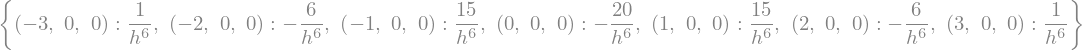

In [56]:
fd_gen_1d_stencil(2,6,0,"x")


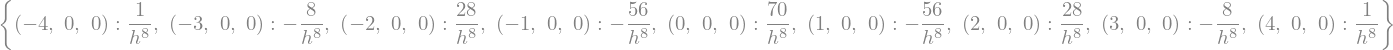

In [57]:
fd_gen_1d_stencil(2,8,0,"x")


In [58]:
k,expr = list(fd1.items())[0]
test = [] 
test.append(make_function([expr],printer,get_fname(k),abi,output,out_abi,template_args=[("typename","view_t")],additional_inputs=["i","j","k"],cse_optims=None))

In [59]:
print(test[0])

template< typename view_t >
static void KOKKOS_INLINE_FUNCTION
fd_der_x_l1(
	view_t u,
	int i,
	int j,
	int k,
	double invh,
	double * __restrict__ du
)
{
	*du = (1.0/60.0)*invh*(24*u(i+1,j,k) - 2*u(i+2,j,k) + 35*u(i,j,k) - 80*u(i-1,j,k) + 30*u(i-2,j,k) - 8*u(i-3,j,k) + u(i-4,j,k));
}



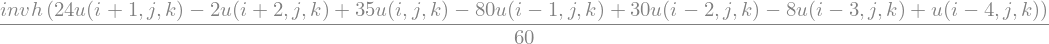

In [60]:
expr